In [1]:
from made.data_pipeline.data.datacomp_handler import decode_webdataset, get_next_batch
from made.data_pipeline.utils import collect_tar_files

In [17]:
dataset = iter(decode_webdataset(
    collect_tar_files("/home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output"), # 20220 samples read in 1m 10s
    get_images=True,
    get_captions=True,
    batch_size=2000
))

2025-06-20 16:37:59,923	INFO utils.py:50 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


In [3]:

from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
processor = AutoProcessor.from_pretrained("leobaro/DFN-public")
model = AutoModelForZeroShotImageClassification.from_pretrained("leobaro/DFN-public").eval().to("cuda")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [18]:
uid_score = {}
while True:
    batch = get_next_batch(dataset)
    if batch is None:
        break
    uids, images, captions = batch
    print("New batch!")
    for uid, img, txt in zip(uids, images, captions):
        try:
            inputs = processor(text=[txt], images=[img], return_tensors="pt", padding=True, truncation=True, max_length=77).to("cuda")
        except Exception as e:
            print(e)
            continue
        outputs = model(**inputs)

        uid_score[uid] = (outputs.logits_per_image.item(), uid, img, txt)
    break

New batch!


In [21]:
uid_score

{'cf08dd3e35c03806c92f907586ee2d7e': (4.766545295715332,
  'cf08dd3e35c03806c92f907586ee2d7e',
  <PIL.Image.Image image mode=RGB size=316x232>,
  'Lovecars spends the day with Collecting Cars'),
 '00ffeae2d5c8a1730fc997f09ec9c408': (3.3331656455993652,
  '00ffeae2d5c8a1730fc997f09ec9c408',
  <PIL.Image.Image image mode=RGB size=400x300>,
  'Nobody Drawing - Blue Paperman by Aged Pixel'),
 '7c23f2299d3695d19b78861b4d650eaf': (1.7183082103729248,
  '7c23f2299d3695d19b78861b4d650eaf',
  <PIL.Image.Image image mode=RGB size=159x106>,
  'photograph of aurora with Sony Alpha mirrorless camera for astrophotography in Valdez, Alaska'),
 'e5c92b84e3ec63f542e78417255d4ddb': (2.6800053119659424,
  'e5c92b84e3ec63f542e78417255d4ddb',
  <PIL.Image.Image image mode=RGB size=512x512>,
  'polycarbonate rectangular basement window well cover at'),
 'f531f313748614decc149435ce0e5d89': (3.4071872234344482,
  'f531f313748614decc149435ce0e5d89',
  <PIL.Image.Image image mode=RGB size=256x256>,
  'arrow, ba

In [25]:
image_similarity_scores = {uid: tuple_elements[0] for uid, tuple_elements in uid_score.items()}


In [28]:
import pandas as pd
pd.DataFrame(image_similarity_scores.values()).describe()

,0
count,2000.000000
mean,2.982759
std,1.443148
min,-1.232026
25%,1.956721
50%,3.109962
75%,4.091914
max,6.505108


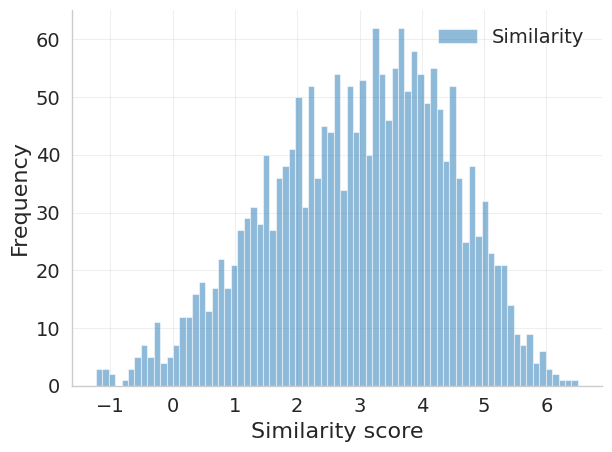

In [31]:
from made.data_pipeline.utils import set_plotting_configuration
set_plotting_configuration()
import matplotlib.pyplot as plt
sim_scores = list(image_similarity_scores.values())

plt.hist(sim_scores, bins=75, label="Similarity", alpha=0.5)

# plt.title("Similarity scores distribution (DFN)")
plt.xlabel("Similarity score")
plt.ylabel("Frequency")
#plt.axvline(x=np.mean(sim_scores), color='red', linestyle='--', label='mean')
#plt.axvline(x=np.percentile(sim_scores, 25), color='grey', linestyle='--', label='25th and 75th percentiles')
#plt.axvline(x=np.percentile(sim_scores, 75), color='grey', linestyle='--')
plt.legend()
plt.savefig("dfn_scores_distribution.png", dpi=300)
plt.show()

In [32]:
percentile_ranges = [(x,x+10) for x in range(50, 100, 10)]
percentile_ranges

[(50, 60), (60, 70), (70, 80), (80, 90), (90, 100)]

In [55]:
image_similarity_scores = [tuple_elements[0] for uid, tuple_elements in uid_score.items()]
images = [tuple_elements[2] for uid, tuple_elements in uid_score.items()]
captions = [tuple_elements[3] for uid, tuple_elements in uid_score.items()]

In [56]:
sorted_indices = sorted(range(len(image_similarity_scores)), key=lambda i: image_similarity_scores[i])
sorted_image_similarity_scores = [image_similarity_scores[i] for i in sorted_indices]
sorted_images = [images[i] for i in sorted_indices]
sorted_captions = [captions[i] for i in sorted_indices]

In [57]:
percentile_ranges_min_max = []
for percentile_range in percentile_ranges:
    p_min, p_max = np.percentile(sorted_image_similarity_scores, percentile_range[0]), np.percentile(sorted_image_similarity_scores, percentile_range[1])
    print(f"{percentile_range[0]}-{percentile_range[1]}", round(p_min, 3), round(p_max, 3))
    percentile_ranges_min_max.append((p_min, p_max))

50-60 3.11 3.518
60-70 3.518 3.882
70-80 3.882 4.264
80-90 4.264 4.78
90-100 4.78 6.505


In [58]:
def get_samples_and_scores_from_percentile_range(p_min, p_max, scores, images, captions):
    ok_indexes = [i for i, score in enumerate(scores) if p_min <= score <= p_max]
    return [images[i] for i in ok_indexes], [captions[i] for i in ok_indexes], [scores[i] for i in ok_indexes]

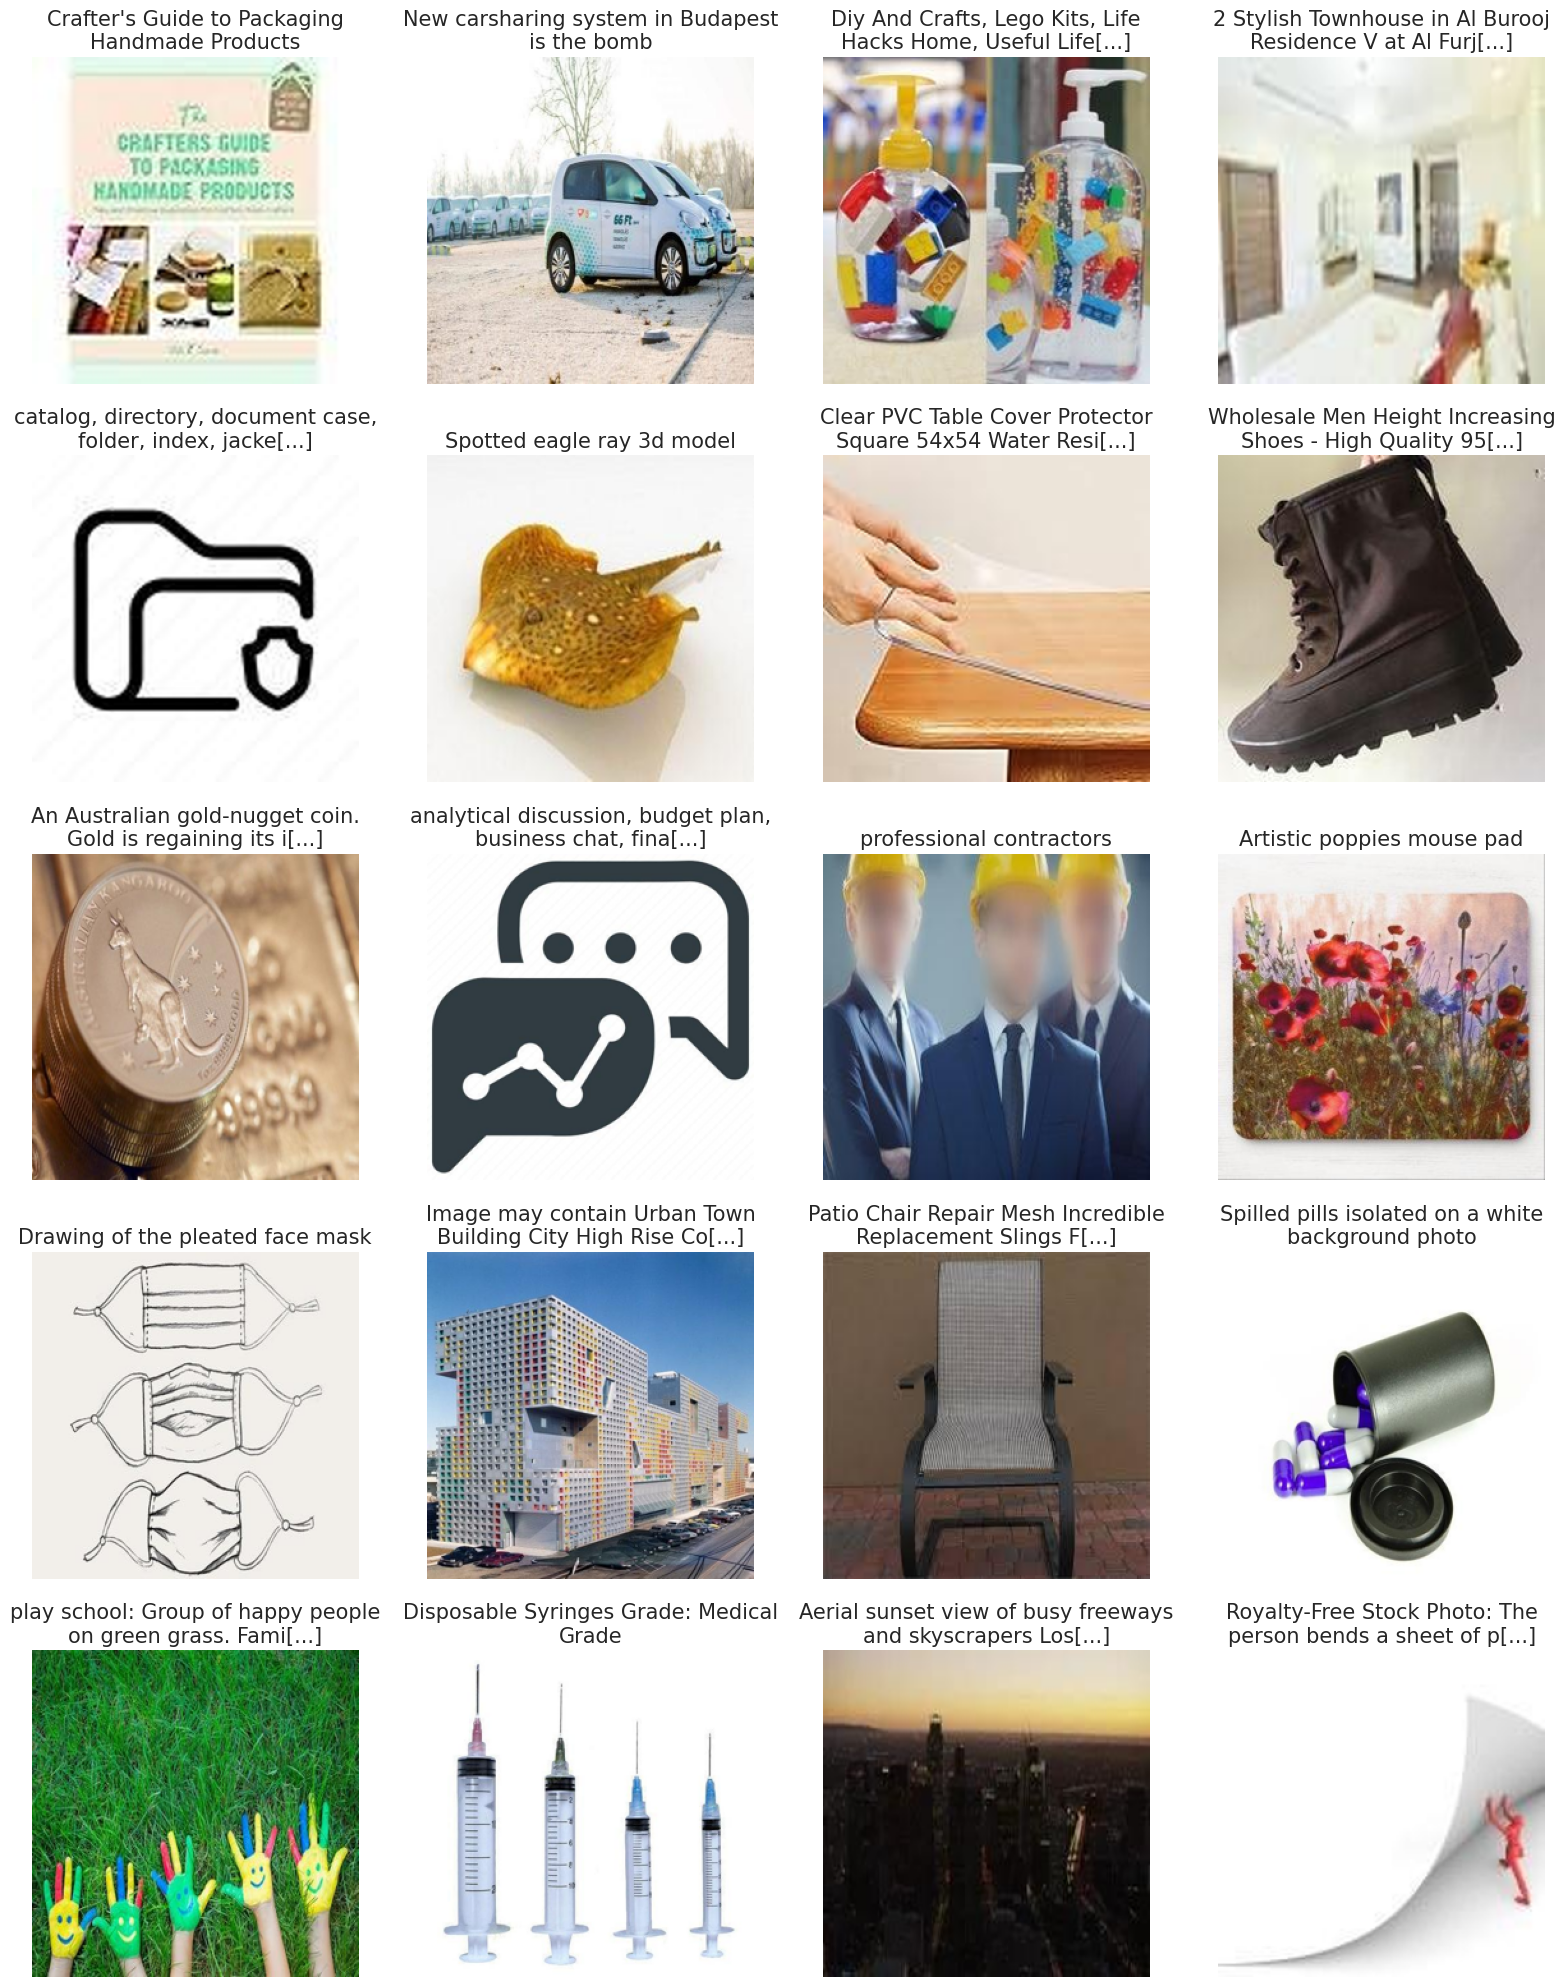

In [66]:
num_rows = len(percentile_ranges_min_max)
num_cols = 4
import textwrap
plt.rcParams['figure.autolayout'] = False
fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 4 * num_rows))

for j, percentile_range in enumerate(percentile_ranges_min_max):
    
    images, captions, scores = get_samples_and_scores_from_percentile_range(
        percentile_range[0], percentile_range[1], sorted_image_similarity_scores, sorted_images, sorted_captions)
    

    for i, (image, caption, score) in enumerate(zip(images[0:num_cols], captions[0:num_cols], scores[0:num_cols])):
        axes[j][i].imshow(image.resize((256, 256)))
        ax_title = "\n".join(textwrap.wrap(caption, width=35))
        if len(ax_title) > 55:
            ax_title=ax_title[:55]+"[...]"
        axes[j][i].set_title(ax_title, fontsize=15)
        axes[j][i].axis("off")


#plt.subplots_adjust(hspace=0.3, wspace=0.2)        
fig.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for suptitle
fig.subplots_adjust(top=0.97, bottom=0.01, left=0.01, right=0.99)

fig.savefig("images_similarity_percentiles.png", dpi=150)
plt.show()